--- ЗАГАЛЬНА ІНФОРМАЦІЯ ---
<class 'pandas.DataFrame'>
RangeIndex: 7216 entries, 0 to 7215
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          7216 non-null   int64  
 1   NAME        7216 non-null   str    
 2   CITY        7216 non-null   str    
 3   STATE       7216 non-null   str    
 4   TYPE        7216 non-null   str    
 5   LATITUDE    7216 non-null   float64
 6   LONGITUDE   7216 non-null   float64
 7   BEDS        6640 non-null   float64
 8   POPULATION  6607 non-null   float64
dtypes: float64(4), int64(1), str(4)
memory usage: 507.5 KB
None

--- СТАТИСТИЧНИЙ ОПИС ---
                 ID     LATITUDE    LONGITUDE         BEDS   POPULATION
count  7.216000e+03  7216.000000  7216.000000  6640.000000  6607.000000
mean   2.515252e+07    37.350477   -92.452613   148.555873   148.714545
std    3.897336e+07     5.801158    16.117919   177.413674   177.587257
min    4.000000e+00   -14.290242  -176.640263 

/tmp/ipykernel_28132/3747426350.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette="viridis")
/tmp/ipykernel_28132/3747426350.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.values, y=type_counts.index, palette="magma")


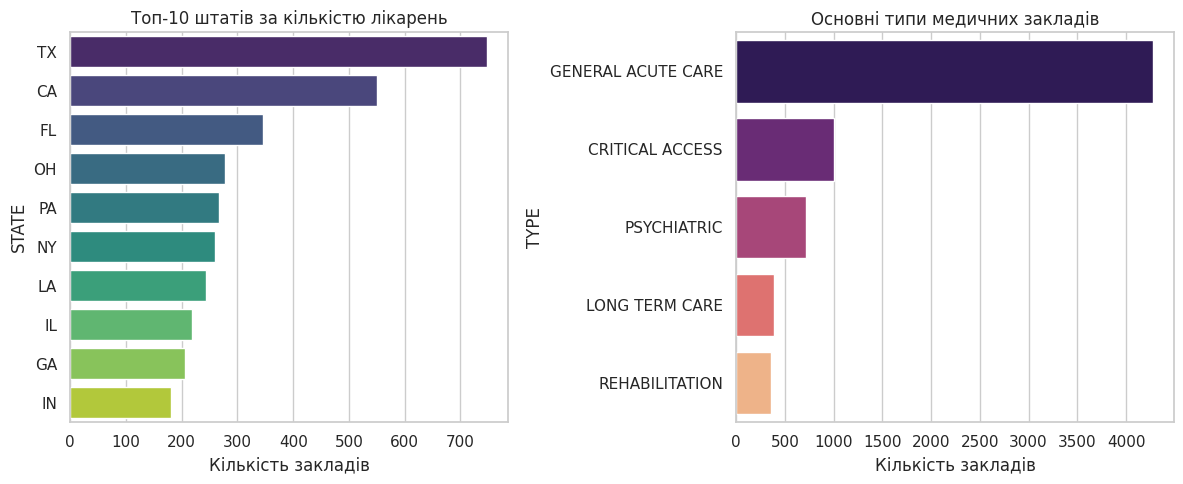

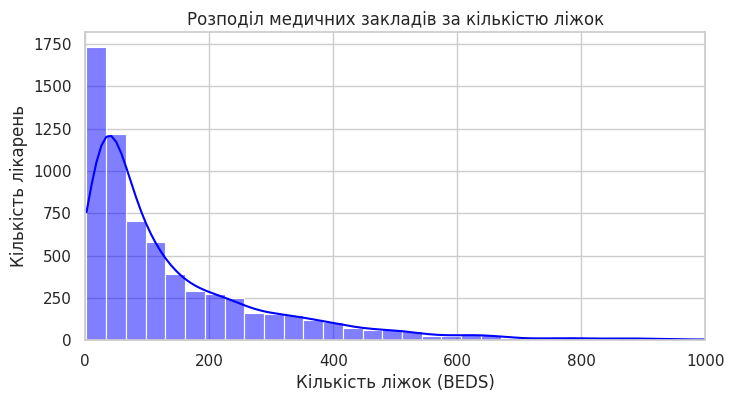

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Завантажуємо очищені дані
df = pd.read_csv("../data/processed/clean_hospitals.csv")

# 2. Перевіряємо загальну інформацію та пропуски
print("--- ЗАГАЛЬНА ІНФОРМАЦІЯ ---")
print(df.info())
print("\n--- СТАТИСТИЧНИЙ ОПИС ---")
print(df.describe())

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 3. Графік 1: Топ-10 штатів за кількістю лікарень
plt.subplot(1, 2, 1)
state_counts = df['STATE'].value_counts().head(10)
sns.barplot(x=state_counts.values, y=state_counts.index, palette="viridis")
plt.title("Топ-10 штатів за кількістю лікарень")
plt.xlabel("Кількість закладів")

# 4. Графік 2: Розподіл лікарень за типами (TYPE)
plt.subplot(1, 2, 2)
type_counts = df['TYPE'].value_counts().head(5) # візьмемо топ-5 основних типів
sns.barplot(x=type_counts.values, y=type_counts.index, palette="magma")
plt.title("Основні типи медичних закладів")
plt.xlabel("Кількість закладів")

plt.tight_layout()
plt.show()

# 5. Аналіз потужності (кількості ліжок)
plt.figure(figsize=(8, 4))
sns.histplot(df['BEDS'].dropna(), bins=50, kde=True, color="blue")
plt.title("Розподіл медичних закладів за кількістю ліжок")
plt.xlabel("Кількість ліжок (BEDS)")
plt.ylabel("Кількість лікарень")
plt.xlim(0, 1000) # обмежуємо x, щоб викиди не псували масштаб
plt.show()

/tmp/ipykernel_28132/184827833.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_beds_df, y='TYPE', x='BEDS', ax=axes[1], palette="Set2")


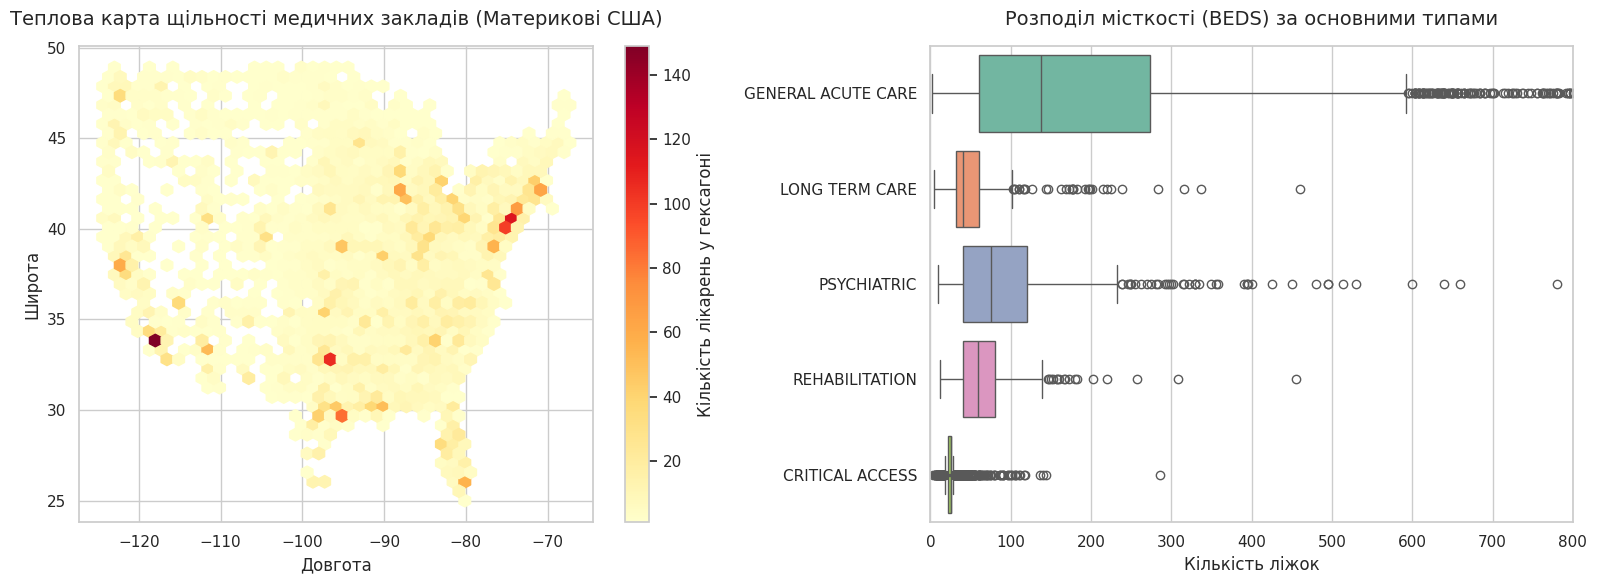

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю
sns.set_theme(style="whitegrid", palette="muted")

# 1. Створюємо фігуру з двома крутими графіками
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Теплова карта географічної щільності (Hexbin)
# Фільтруємо координати, щоб прибрати Аляску та Гаваї для красивішого масштабу (тільки материкова частина США)
mainland_df = df[(df['LONGITUDE'] > -130) & (df['LONGITUDE'] < -65) & (df['LATITUDE'] > 25) & (df['LATITUDE'] < 50)]

hb = axes[0].hexbin(mainland_df['LONGITUDE'], mainland_df['LATITUDE'], gridsize=40, cmap='YlOrRd', mincnt=1)
axes[0].set_title("Теплова карта щільності медичних закладів (Материкові США)", fontsize=14, pad=15)
axes[0].set_xlabel("Довгота")
axes[0].set_ylabel("Широта")
cb = fig.colorbar(hb, ax=axes[0])
cb.set_label('Кількість лікарень у гексагоні')

# Графік 2: Boxplot (розподіл ліжко-місць за топ-5 типами лікарень)
# Це покаже викладачу, що ти розумієш, як шукати викиди (outliers)
top_5_types = df['TYPE'].value_counts().nlargest(5).index
filtered_beds_df = df[df['TYPE'].isin(top_5_types)]

sns.boxplot(data=filtered_beds_df, y='TYPE', x='BEDS', ax=axes[1], palette="Set2")
axes[1].set_title("Розподіл місткості (BEDS) за основними типами", fontsize=14, pad=15)
axes[1].set_xlabel("Кількість ліжок")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 800) # Обрізаємо екстремальні викиди для читабельності

plt.tight_layout()
plt.show()